In [1]:
#Importing packages
import argparse
import os
from torch.utils.data import DataLoader
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

from chromadb import PersistentClient as PersistentClient
from chromadb.errors import InternalError as CollectionError

#library functions
import helper_code.dataloading as dataloading
import helper_code.data_vis as data_vis
import helper_code.model_functions as model_functions


d:\Projects\alertcalifornia-anomaly-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
torch.manual_seed(1234)

Loading the train, validation, and test data

In [3]:
labels_csv = r"camera_data/coronado_hills_data.csv"

device = 'cuda'

model_path = 'weights/'
model_name = "deepsad_init_model.pth"

data = dataloading.get_data(labels_csv, r"camera_data/images/", replace_images = False)

train, val, test = dataloading.get_train_val_test(data = data, output_csvs=True)

new_label_column = train['label'].sample(len(train) // 3)

train['label'] = new_label_column

labeled_train = train.dropna(axis = 0)

train['label'] = train['label'].fillna(-5)

train_dataset, val_dataset, test_dataset = dataloading.get_datasets(train, val, test)

labeled_train_dataset, _, _ = dataloading.get_datasets(labeled_train, val, test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
labeled_train_dataloader = DataLoader(labeled_train_dataset, batch_size=32, shuffle=True, pin_memory=True)

val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, pin_memory=True)


100%|██████████| 7490/7490 [00:01<00:00, 7110.35it/s]


Instantiating the pre-trained model

In [4]:
encoder = model_functions.create_encoder()
encoder.to(device);

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Instantiating the training settings

In [5]:
loss_func = model_functions.DeepSADLoss(encoder, train_dataloader, device, eta = 2)
optimizer = optim.Adam(encoder.parameters(), lr=2e-5, weight_decay=1e-6) 
num_epochs = 1

Training the model

In [6]:
losses = model_functions.train_model(encoder, train_data=train_dataloader, 
                                num_epochs=num_epochs, loss_func=loss_func, 
                                optimizer=optimizer, name = 'deepsad_init_model.pth', path = 'weights/', device=device)

Processing batch 140 in epoch 0: : 141it [01:55,  1.23it/s]


Text(0.5, 1.0, 'Image to Embeddings Model Losses')

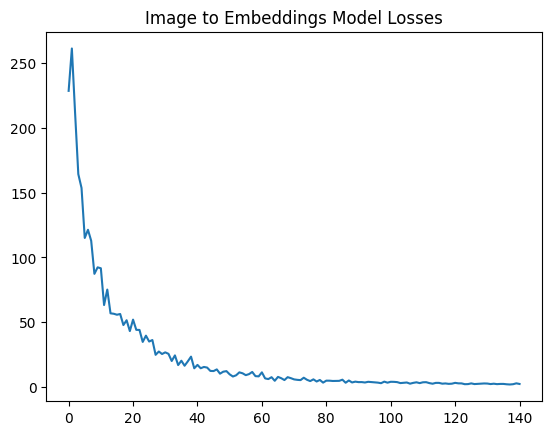

In [7]:
import matplotlib.pyplot as plt

plt.plot(list(range(len(losses))), losses)
plt.title("Image to Embeddings Model Losses")

Saving the embeddings generated by this model

In [8]:
client = PersistentClient(path="embeddings/") 

try:
    client.delete_collection(name="train_embeddings")
except Exception:
    pass

try:
    client.delete_collection(name="val_embeddings")
except Exception:
    pass

try:
    client.delete_collection(name="test_embeddings")
except Exception:
    pass

dataloading.save_full_embeddings(encoder, labeled_train_dataloader, 
                        "train_embeddings", persist_directory = "embedding_data/", 
                        device = device)


dataloading.save_full_embeddings(encoder, val_dataloader, 
                        "val_embeddings", persist_directory = "embedding_data/", 
                        device = device)

dataloading.save_full_embeddings(encoder, test_dataloader, 
                        "test_embeddings", persist_directory = "embedding_data/", 
                        device = device)
    
    
#Embeddings of training data, used to train the classification head
train_embeddings, train_labels, _, _ = dataloading.load_full_embeddings(labeled_train, "train_embeddings", persist_directory = "embedding_data/")
train_embedding_dataset = dataloading.CustomEmbeddingDataset(train_embeddings, train_labels)
train_embedding_dataloader = DataLoader(train_embedding_dataset, batch_size=32, shuffle=True, pin_memory=True)

#Embeddings of validation data, used to display results
val_embeddings, val_labels, _, _ = dataloading.load_full_embeddings(val, "val_embeddings", persist_directory = "embedding_data/")
val_embedding_dataset = dataloading.CustomEmbeddingDataset(val_embeddings, val_labels)
val_embedding_dataloader = DataLoader(val_embedding_dataset, batch_size=32, shuffle=True, pin_memory=True)

#Embeddings of test data, used to evaluate classification head
test_embeddings, test_labels, _, _ = dataloading.load_full_embeddings(test, "test_embeddings", persist_directory = "embedding_data/")
test_embedding_dataset = dataloading.CustomEmbeddingDataset(test_embeddings, test_labels)
test_embedding_dataloader = DataLoader(test_embedding_dataset, batch_size=32, shuffle=True, pin_memory=True)

InternalError: Collection [train_embeddings] already exists

Visualizing the first two principal axes of the embedding space

In [ ]:
reduced_embeddings, labels = model_functions.reduce_pca(train_embeddings, train_labels, dimensions=4)

#idx = (labels == 1).to_numpy()

#reduced_embeddings = reduced_embeddings[idx]

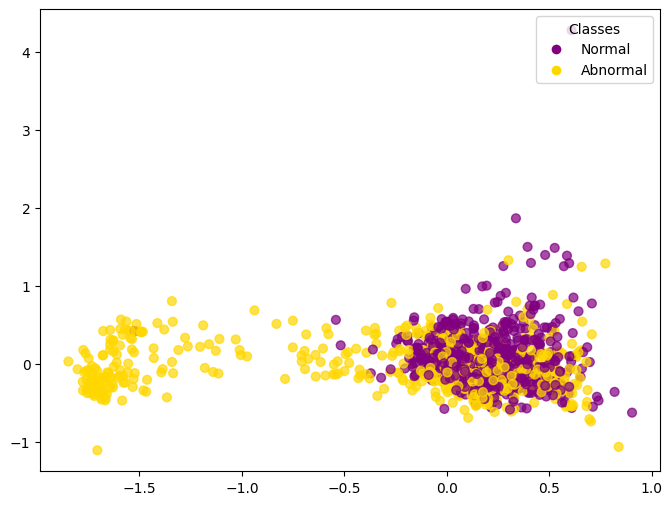

In [ ]:
data_vis.plot_data(reduced_embeddings, labels, pcx = 1, pcy = 2)
plt.title("First two axes of embedding space")

Training classification head

In [ ]:
losses = []

classification_head = model_functions.ClassificationHead()
classification_head.to(device)

head_criterion = nn.CrossEntropyLoss()
head_optimizer = optim.Adam(classification_head.parameters(), lr=2e-3) # Optimize only the new head

head_name = model_path + model_name[:-4] + "_head.pth"



num_epochs = 1
for epoch in range(num_epochs):
    classification_head.train() # Set model to training mode

    for batch in tqdm(train_embedding_dataloader, desc = f"Processing batches in epoch {epoch}"):
        embeddings = batch['embeddings'].to(device).float()
        labels = batch['labels'].to(device).long()

        head_optimizer.zero_grad()
        outputs = classification_head(embeddings)
        loss = head_criterion(outputs, labels)
        loss.backward()
        head_optimizer.step()

        losses.append(loss.item())
torch.save(classification_head.state_dict(), head_name)


#Report training and validation accuracy
classification_head.eval()

Processing batches in epoch 0: 100%|██████████| 47/47 [00:04<00:00, 10.94it/s]


ClassificationHead(
  (norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (head): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=2, bias=True)
  )
)

Testing classification head outputs

In [ ]:
embeddings = torch.Tensor(test_embeddings.to_numpy()).to(device)
labels = torch.Tensor(test_labels.to_numpy()).to(device)


outputs = classification_head(embeddings)

(torch.argmax(outputs, dim = -1) == labels).float().mean().item()

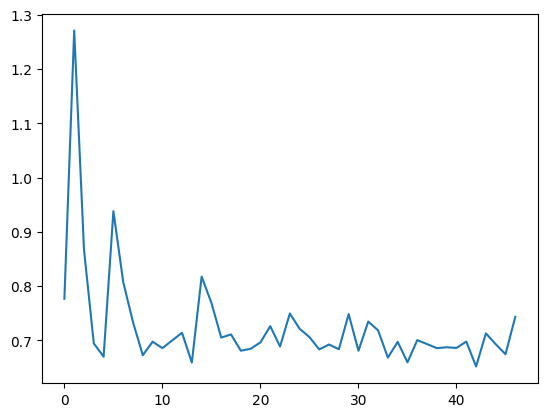

In [ ]:
plt.plot(list(range(len(losses))), losses)